In [105]:
import sys
sys.path.append('..')
import selex_dca, utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

import utils
import selex_dca
import selex_distribution, energy_models, tree, data_loading, training, callback, sampling, realistic_sampling
import diagnostic, specialized_models

from matplotlib import cm
import pickle

In [70]:
tr = tree.Tree()
tr.add_node(-1, name = "round 1 with selection")

round_ids = ['initial_library', 'after_1_selection']

selected_modes = torch.BoolTensor(
    [[1, 0]]
)

n_selection_rounds, n_modes = selected_modes.size()
assert n_selection_rounds == tr.get_n_nodes()
n_rounds = n_selection_rounds + 1
assert len(round_ids) == n_rounds

In [13]:
L, q = 45, 4
dtype = torch.float

In [56]:
generator = torch.Generator().manual_seed(1)
h_teacher = torch.randn(L, q, dtype=dtype, generator=generator)
wt_oh = sampling.sample_indep_sites(h_teacher, n_samples=1, generator=generator, beta=2.0).squeeze()
mutation_rate = 0.1
k_teacher = utils.field_from_wildtype(wt_oh, mutation_rate)
Ns0_teacher = energy_models.IndepSites(k_teacher)
sel_teacher = energy_models.IndepSites(h_teacher)
# sel.normalize()
unbound = energy_models.ConstantEnergy(-25.0)
ps_teacher = selex_distribution.MultiModeDistribution(sel_teacher, unbound, normalized=True)
model_teacher = selex_distribution.MultiRoundDistribution(Ns0_teacher, ps_teacher, tr, selected_modes)
model_teacher.train(mode=False);

In [61]:
sample_round_zero = lambda n: sampling.sample_indep_sites(k_teacher, n)
def ps_round_t(x, t):
    return torch.exp(-ps_teacher.compute_energy(x, selected_modes[t]).detach())

total_reads = torch.tensor([0, 1, 2]) + 10**6
initial_pop_size = 10**7

In [81]:
population, sequences_unique = realistic_sampling.generate_realistic(sample_round_zero, ps_round_t, initial_pop_size, n_selection_rounds)

Extracting unique sequences and counts from initial library...
Starting selection round 1 of 1...


In [65]:
from importlib import reload
reload(realistic_sampling)

<module 'realistic_sampling' from '/home/scrotti/Aptamer2025py/experiments/../realistic_sampling.py'>

In [82]:
sequences_oh = realistic_sampling.read_multinomial(population, total_reads, sequences_unique)
sequences = [s.argmax(dim=-1) for s in sequences_oh]

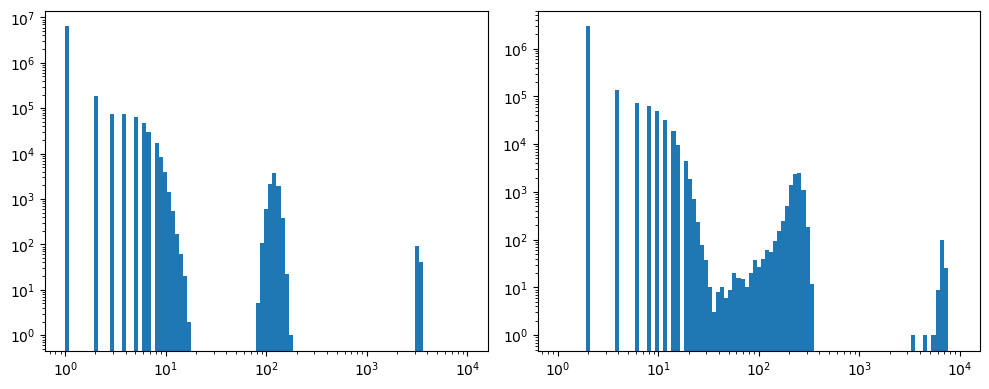

In [64]:
fig, axes = plt.subplots(1, n_rounds, figsize=(10,4))

for t in range(n_rounds):
    ax = axes[t]
    ax.hist(population[t], bins=np.logspace(0, 4, 100))
    ax.set_yscale('log')
    ax.set_xscale('log')

fig.tight_layout()

In [73]:
from pathlib import Path

def decode_sequence_int(seq_encoded, tokens=utils.TOKENS_DNA):
    # seq_encoded: 1D tensor/list/ndarray of ints
    if hasattr(seq_encoded, "tolist"):
        seq_encoded = seq_encoded.tolist()
    return "".join(tokens[int(i)] for i in seq_encoded)

def write_round_to_file(seq_count_pairs, dirpath, filename):
    dirpath = Path(dirpath)
    dirpath.mkdir(parents=True, exist_ok=True)

    filepath = dirpath / f"{filename}.txt"

    with open(filepath, "w") as f:
        for seq, count in seq_count_pairs:
            f.write(f"{decode_sequence_int(seq)}\t{count.item()}\n")

In [97]:
seq_counts = [list(zip(*utils.sequences_unique_and_counts(s)[0:2])) for s in sequences]

In [100]:
dirpath = 'saved/ab6_teacher_student'

for t in range(n_rounds):
    write_round_to_file(seq_counts[t], dirpath, round_ids[t])

In [103]:
k, h = training.init_from_indep_sites(sequences_oh, total_reads)
k = utils.zerosum_gauge_bias(k)
h = utils.zerosum_gauge_bias(h)

In [107]:
np.savetxt(dirpath + '/Ns0_field.txt', k.numpy())
np.savetxt(dirpath + '/ps_field.txt', h.numpy())

In [113]:
k_ = torch.log(utils.get_freq_single_point(sequences_oh[0]))
k_ = utils.zerosum_gauge_bias(k_)
h_ = torch.log(utils.get_freq_single_point(sequences_oh[1])) - k_
h_ = utils.zerosum_gauge_bias(h_)

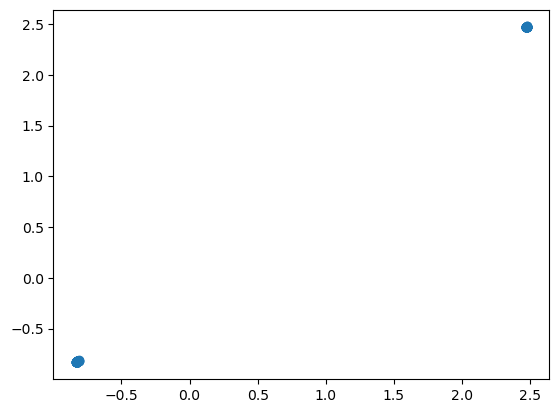

In [115]:
plt.scatter(k, k_)

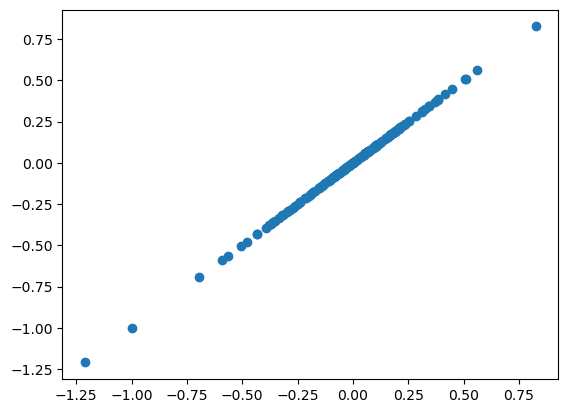

In [114]:
plt.scatter(h, h_)